<a href="https://colab.research.google.com/github/oviccenzo/inteligencia-artificial/blob/main/dataset_de_titanic_da_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [ ]:
#1 carregar dataset do titanic
df = pd.read_csv("titanic.csv")

In [ ]:
#1 linha do dataset do titanci
print("\nPrimeira linha do dataset: ")
print(df.head())


Primeira linha do dataset: 
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [ ]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [ ]:
#Esse é a informação do dataset de titanic
print("\nInformações do dataset: ")
print(df.info())


Informações do dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
# 2 Pré processamento
#Converter variáveis categóricas para numéricas
le_dict = {}

for col in df.select_dtypes(include='object').columns:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  le_dict[col] = le

In [ ]:
#Separar features e target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
print("\nFeatures utilizados: ")
print(X.columns)


Features utilizados: 
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [ ]:
#3 divisão treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
#5 availiar modelo
y_pred = model.predict(X_test)

print("\nAvaliação do modelo: ")
print(classification_report(y_test, y_pred))


Avaliação do modelo: 
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       105
           1       0.86      0.76      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Feature importance
importances = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature" : X.columns,
    "importances" : importances
})


In [ ]:
feature_importances = feature_importance.sort_values(
    by="importances",
    ascending=False
)

In [ ]:
print(f"Feature importances")
print(feature_importances)

Feature importances
        feature  importances
3           Sex     0.237026
7        Ticket     0.134507
8          Fare     0.119133
4           Age     0.113675
2          Name     0.108368
0   PassengerId     0.100064
1        Pclass     0.057009
9         Cabin     0.056867
5         SibSp     0.027896
6         Parch     0.023108
10     Embarked     0.022348


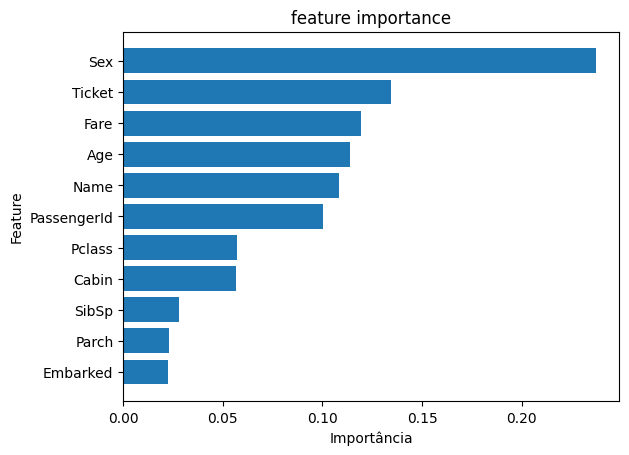

In [ ]:
plt.figure()
plt.barh(feature_importances["feature"], feature_importances["importances"])
plt.gca().invert_yaxis()
plt.title("feature importance")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

In [ ]:
#Sha
# Criar o explainer
Explainer = shap.TreeExplainer(model, X_train)

#Calcular os valores do shap
shap_value = Explainer.shap_values(X_test, check_additivity=False)

#Selecionar uma classes do titanic
shap_class = shap_value[:, :, 1]

 99%|===================| 355/358 [00:15<00:00]       

In [ ]:
#Gerar um grafico de um beeswam (enxame de abelhas)
shap.summary_plot(
    shap_class,
    X_test,
    feature_names = X_test.columns
)

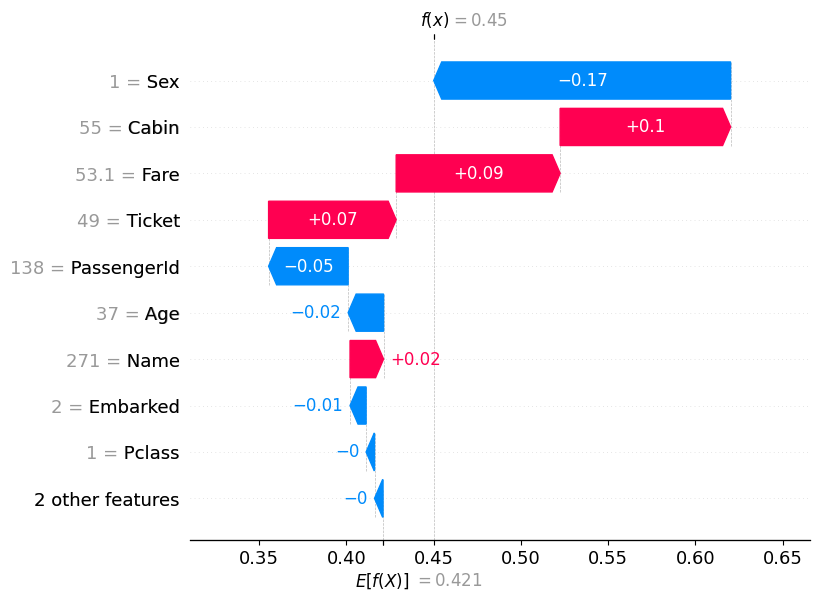

In [ ]:
# Explicação de uma previsão individual

index = 10
shap.plots.waterfall(
    shap.Explanation(
        values=shap_class[index],
        base_values=Explainer.expected_value[1],
        data=X_test.iloc[index],
        feature_names=X_test.columns
    )
)

In [ ]:
#Exemplo de previsão com explicação com as probabilidade e valores de amostras
index = 10
sample = X_test.iloc[[index]]
prediction = model.predict(sample)[0]
prob = model.predict_proba(sample)[0]
print(f"Previsão: {prediction}")
print(f"Probabilidade: {prob}")
print(f"Valores da amostras {sample}")


Previsão: 0
Probabilidade: [0.55 0.45]
Valores da amostras      PassengerId  Pclass  Name  Sex   Age  SibSp  Parch  Ticket  Fare  Cabin  \
137          138       1   271    1  37.0      1      0      49  53.1     55   

     Embarked  
137         2  
